In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [8]:
# ---------------------------
# Naming convention helpers
# ---------------------------

def parse_slice_name(slice_name: str):
    """
    Expects names like:
      "alpha_mu"  (sweeps alpha vs mu)
      "mu_d"      (sweeps mu vs d)
      "alpha_d"   (sweeps alpha vs d)
      "alpha_rho" (sweeps alpha vs rho)
      "mu_rho"    (sweeps mu vs rho)
      "d_rho"     (sweeps d vs rho)
    """
    parts = slice_name.split("_")
    if len(parts) != 2:
        raise ValueError(f"slice_name must look like 'alpha_mu' (got {slice_name!r})")
    return parts[0], parts[1]  # (var1, var2)

def choose_axes(var1: str, var2: str):
    """
    Decide x/y labels. I’ll put the second token on x by default
    so 'alpha_mu' -> x=mu, y=alpha matches your current plots.
    """
    xvar, yvar = var2, var1
    return xvar, yvar


In [9]:
def plot_grid_slice(
    base_dir: str,
    slice_name: str,
    held_vars: str, 
    truth: dict,
    ll_col: str = "loglike",
    contour_deltas=(0.5, 1.0, 2.0, 4.0),
    ll_window: float = 50.0,   # <-- max-ll_window to max
    cmap=None,
):
    var1, var2 = parse_slice_name(slice_name)
    xvar, yvar = choose_axes(var1, var2)

    csv_path = os.path.join(base_dir, f"{slice_name}.csv")
    df = pd.read_csv(csv_path)

    for col in (xvar, yvar, ll_col):
        if col not in df.columns:
            raise ValueError(f"{csv_path} missing column '{col}'. Has: {list(df.columns)}")

    xs = np.sort(df[xvar].unique())
    ys = np.sort(df[yvar].unique())
    XN, YN = len(xs), len(ys)

    LL = np.full((YN, XN), np.nan)
    x_to_j = {x: j for j, x in enumerate(xs)}
    y_to_i = {y: i for i, y in enumerate(ys)}

    for _, row in df.iterrows():
        i = y_to_i[row[yvar]]
        j = x_to_j[row[xvar]]
        LL[i, j] = row[ll_col]
        
    held_text = ""
    if held_vars is None:
        held_list = []
    elif isinstance(held_vars, str):
        held_list = [held_vars]
    else:
        held_list = list(held_vars)

    if len(held_list) > 0:
        pieces = []
        for hv in held_list:
            if hv in truth:
                pieces.append(f"{hv}={truth[hv]:g}")
            else:
                pieces.append(f"{hv}=<fixed>")
        held_text = " (fixed: " + ", ".join(pieces) + ")"


    # ---------------------------
    # Plot: raw loglike heatmap (rescaled) + contours
    # ---------------------------
    plt.figure(figsize=(6, 5))

    LLmax = np.nanmax(LL)
    vmin = LLmax - ll_window
    vmax = LLmax

    im = plt.imshow(
        LL,
        origin="lower",
        aspect="auto",
        extent=[xs.min(), xs.max(), ys.min(), ys.max()],
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )

    plt.colorbar(im, label=ll_col)
    plt.xlabel(xvar)
    plt.ylabel(yvar)
    plt.title(f"2D {ll_col}: {yvar}–{xvar} (shown [{vmin:.1f}, {vmax:.1f}]){held_text}")

    # Contours at max - delta
    deltas = np.array(contour_deltas, dtype=float)
    levels = np.sort(LLmax - deltas)

    plt.contour(
        xs, ys, LL,
        levels=levels,
        colors="white",
        linewidths=1.2,
    )

    if (xvar in truth) and (yvar in truth):
        plt.scatter(truth[xvar], truth[yvar], color="red", marker="x", s=80, label="ground truth")
        plt.legend()

    plt.tight_layout()
    plt.show()

    return xs, ys, LL, csv_path


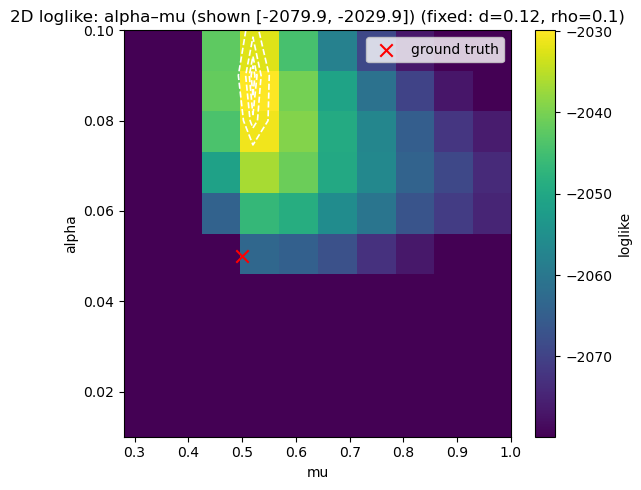

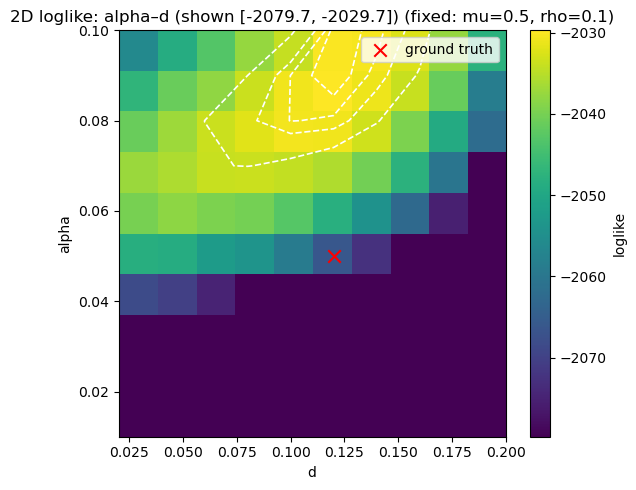

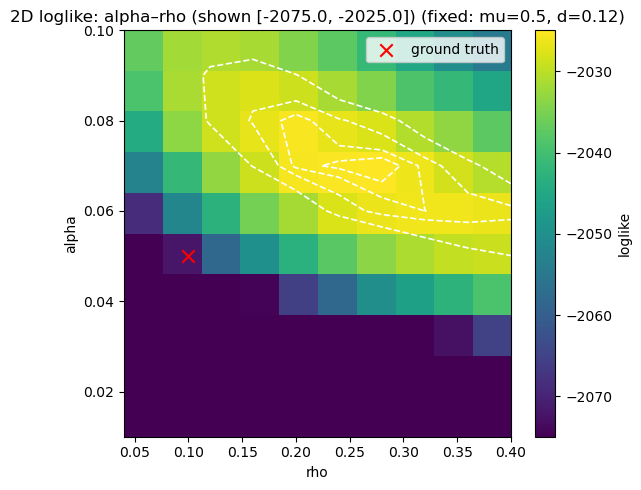

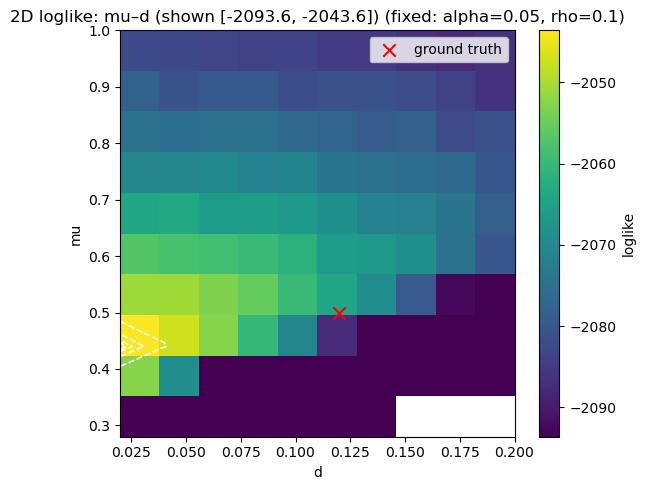

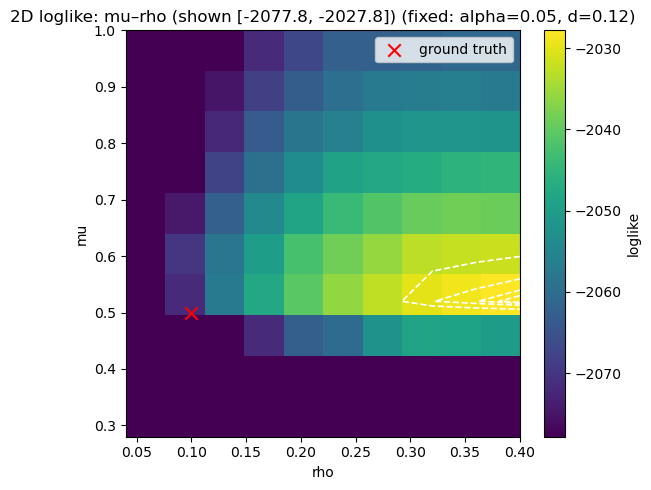

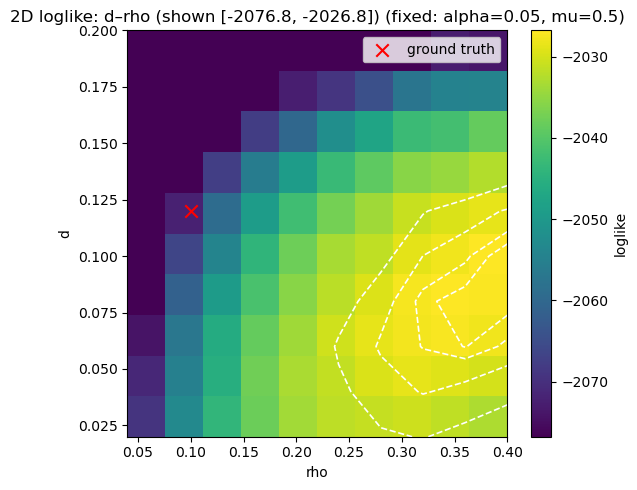

In [10]:
# ---------------------------
# TL (time-limited) truth + plots
# ---------------------------

ALPHA_TRUE = 0.05
MU_TRUE    = 0.5
D_TRUE     = 0.12
RHO_TRUE   = 0.1

truth = {"alpha": ALPHA_TRUE, "mu": MU_TRUE, "d": D_TRUE, "rho": RHO_TRUE}

# All 2D combinations for (alpha, mu, d, rho)
slices = [
    ("alpha_mu",  ["d", "rho"]),
    ("alpha_d",   ["mu", "rho"]),
    ("alpha_rho", ["mu", "d"]),
    ("mu_d",      ["alpha", "rho"]),
    ("mu_rho",    ["alpha", "d"]),
    ("d_rho",     ["alpha", "mu"]),
]

for slice_name, held_vars in slices:
    plot_grid_slice(
        base_dir=BASE_DIR,
        slice_name=slice_name,
        held_vars=held_vars,
        truth=truth,
    )
